# LCEL (LangChain Expression Language)
- LCEL은 LangChain에서 **체인(Chain)** 을 선언적으로 구성하기 위한 언어입니다.

### 주요 특징
- 선언적 구성: 작업의 순서와 흐름을 명시적으로 정의하여, 복잡한 로직을 간결하게 표현할 수 있습니다.
- 파이프 연산자(|) 지원: Unix의 파이프처럼, 함수의 출력을 다음 함수의 입력으로 전달하여 체인을 구성합니다.

> 코드 예제 
```ini
chain = prompt | llm | parser
```

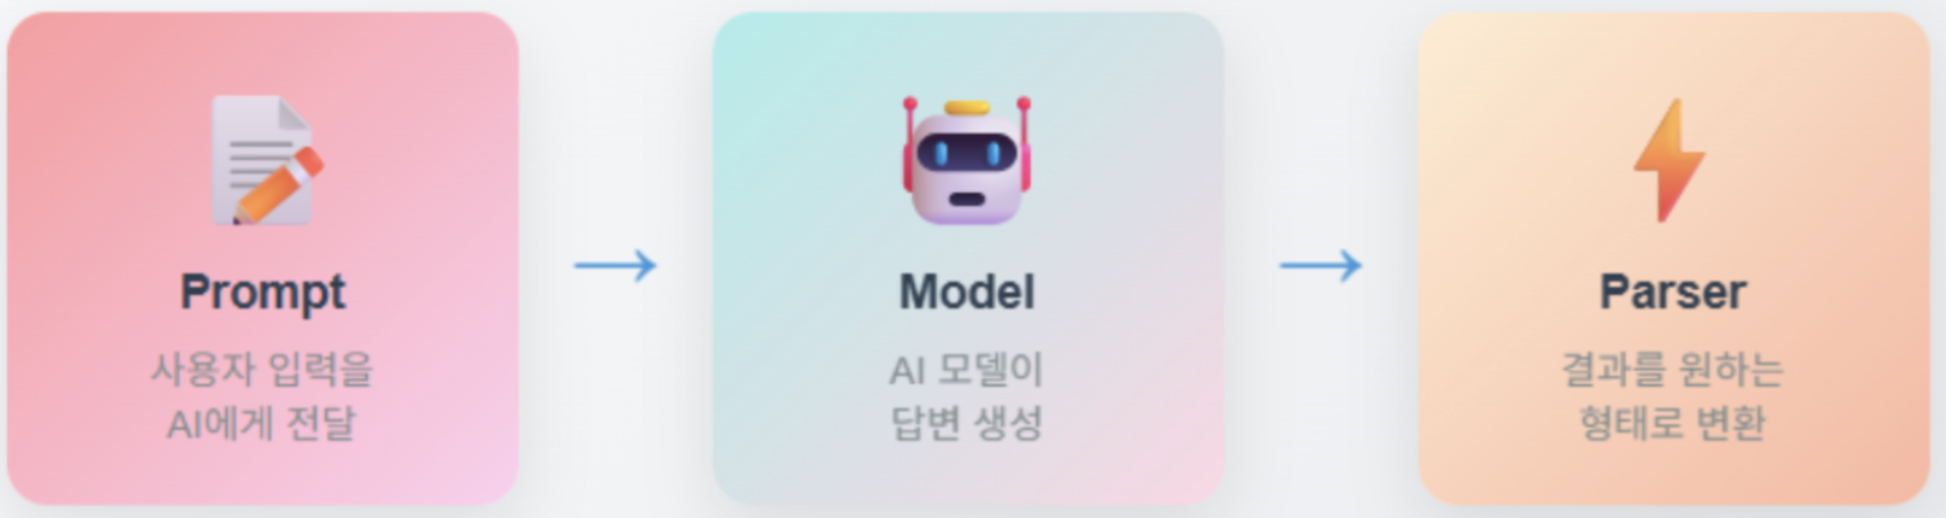

# 스트리밍 (Streaming)
- 긴 응답을 실시간으로 받을 수 있습니다.

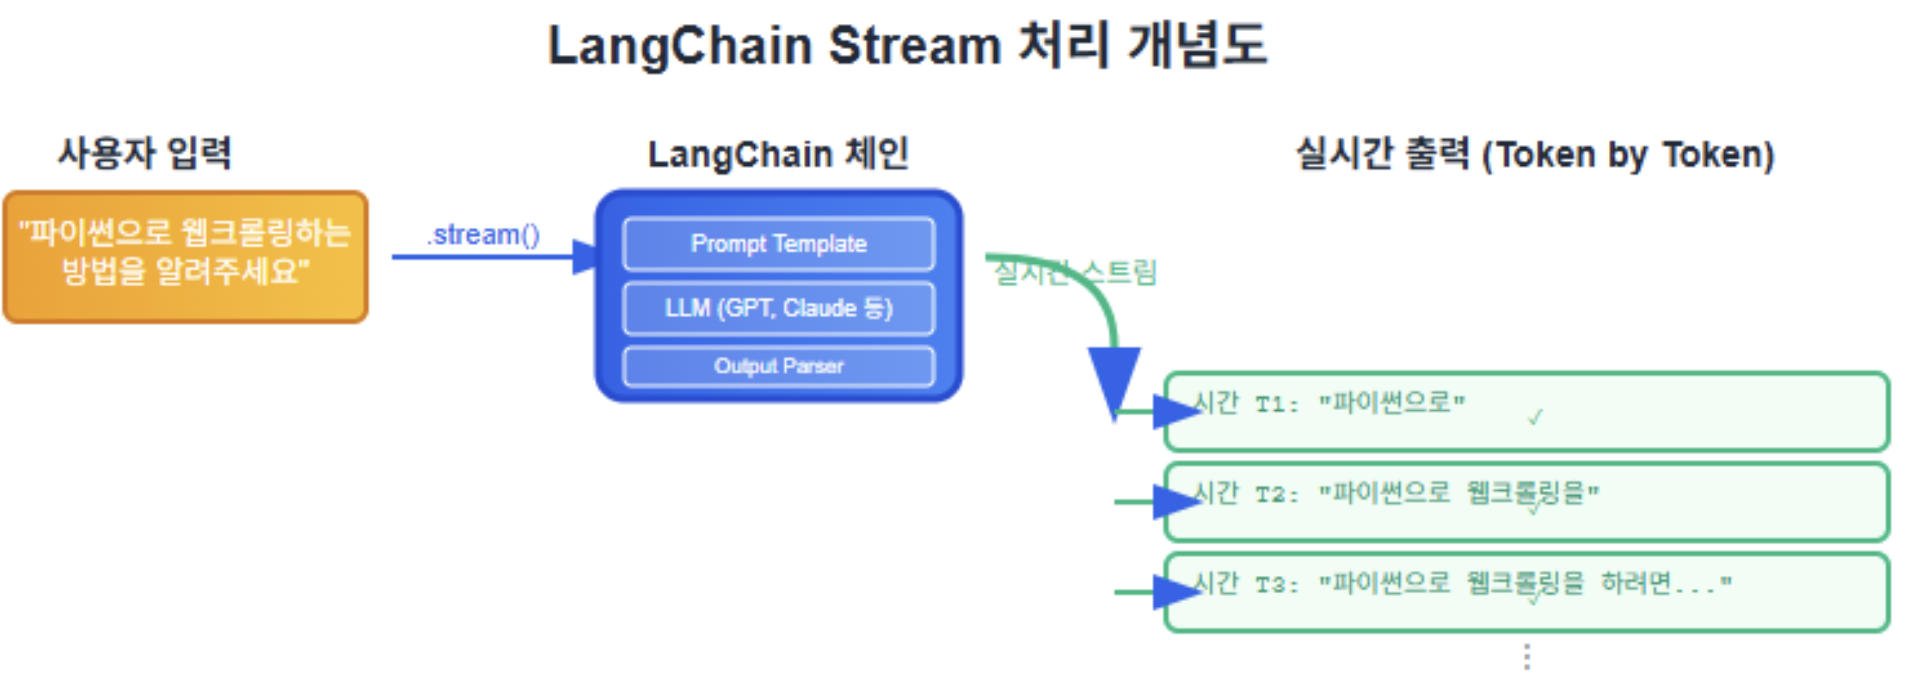

# Model

In [2]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.1,
    top_p=1.0,
    num_predict=256,
    keep_alive="5m"
)

# Parser

In [3]:
from langchain_core.output_parsers import StrOutputParser

# OutputParser 설정
output_parser = StrOutputParser()

# PromptTemplate

In [4]:
from langchain_core.prompts import PromptTemplate

# 긴 응답을 위한 프롬프트
story_prompt = PromptTemplate.from_template(
    template="{topic}에 대한 흥미로운 이야기를 간단하게 써주세요."
)

# Chain

In [5]:
story_chain = story_prompt | llm | output_parser

In [6]:
story_chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='{topic}에 대한 흥미로운 이야기를 간단하게 써주세요.')
| ChatOllama(model='gemma3:4b', num_predict=256, temperature=0.1, top_p=1.0, keep_alive='5m')
| StrOutputParser()

## 스트리밍 실행

In [8]:
import time

# 스트리밍 실행
print("=== 스트리밍 응답 ===")
print("주제: 우주 여행")
print("-" * 30)

for chunk in story_chain.stream({"topic": "우주 여행"}):
    print(chunk, end="", flush=True)
    time.sleep(0.1)  # 스트리밍 효과를 위한 지연

print("\n" + "=" * 30)

=== 스트리밍 응답 ===
주제: 우주 여행
------------------------------
물론입니다. 다음은 우주 여행에 대한 짧은 이야기입니다.

지구에서 멀리 떨어진 곳에 있는 작은 연구소에서 엘리야는 우주 여행에 대한 꿈을 꾸는 과학자였습니다. 그는 수년 동안 다른 행성에서 생명체를 발견하는 방법을 연구해 왔습니다.

어느 날, 그는 우연히 오래된 기록을 발견했습니다. 그 기록은 다른 행성에서 생명체를 발견한 고대 탐험가에 대한 것이었습니다. 그는 그 탐험가들이 행성 간 여행을 하는 데 사용한 특별한 장치를 발견했습니다.

엘리야는 장치를 복원하기 시작했습니다. 그는 수년 동안 밤낮으로 일했습니다. 마침내 장치가 작동하기 시작했습니다. 그는 장치를 사용하여 다른 행성으로 여행을 떠났습니다.

그는 여러 행성을 방문했습니다. 그는 여러 종류의 생명체를 발견했습니다. 그는 그 생명체와 교류했습니다. 그는 그 생명체들이 지구와 마찬가지로 복잡하고 지능적이라는 것을 알게 되었습니다.

그는 지구로 돌아와 자신이 발견한 것을 세상에 알렸습니다. 세상은 그의 발견에 놀랐습니다. 그는 우주
